# 🔍 Scratch / Contam / Other — Defect Detection Pipeline

---

## What does this notebook do?

Imagine you have a camera taking pictures of parts coming off a factory line.  
Some parts are **dirty** (contamination), some have **scratches**, and some have **other weird marks**.  
You want a computer to look at a new photo and say *"hey, that part has a scratch right here!"*  

This notebook teaches a computer to do exactly that — step by step.

---

## The 4 steps

| Step | What happens |
|------|--------------|
| **1. Prepare** | Organise your labeled photos into folders the AI can read |
| **2. Verify** | Double-check every photo has a matching label file |
| **3. Train** | The AI looks at all the labeled photos and learns what defects look like |
| **4. Predict** | Point the AI at new photos — it draws colored masks on any defects it finds |

Run the cells top-to-bottom, in order.

---
## Cell 1 — Imports & Setup

Think of **imports** like opening your toolbox before you start work.  
We grab tools for:
- **pathlib** → working with file paths (finding folders, making folders)
- **shutil** → copying and moving files
- **random** → shuffling the photos so train/val split is random
- **yaml** → reading the `config.yaml` settings file
- **ultralytics** → the YOLOv8 AI library that does the actual detection

In [16]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA RTX 6000 Ada Generation


In [17]:
import shutil
import random
import yaml
from pathlib import Path

# __file__ doesn't exist in a notebook, so we anchor to the notebook's folder instead
SCRIPT_DIR = Path().resolve()

print(f"Working directory: {SCRIPT_DIR}")
print("All tools loaded successfully!")

Working directory: C:\Thawanrat_Internship-Project\ML_pipeline
All tools loaded successfully!


---
## Cell 2 — Load the Config File

Instead of burying numbers inside the code, all the settings live in **`config.yaml`**.

Think of it like the settings menu on a video game — you change things there without touching the engine.

Key settings:
- **`labels_dir`** — the folder that holds your photos + label files
- **`classes`** — what class number means what name (0=contam, 1=scratch, 2=other)
- **`train_ratio`** — how much of your data to use for training vs. checking (0.80 = 80% train, 20% val)
- **`epochs`** — how many times the AI reads through all the training photos
- **`batch_size`** — how many photos the AI looks at at once before updating itself
- **`patience`** — if the AI isn't getting better for this many epochs, stop early

In [18]:
def load_config(path="config.yaml"):
    with open(SCRIPT_DIR / path, encoding="utf-8") as f:
        return yaml.safe_load(f)

def resolve(rel):
    """Turn a relative path string into a full absolute path."""
    return SCRIPT_DIR / rel

cfg = load_config()

print("=== Config loaded ===")
print(f"Labels folder : {cfg['data']['labels_dir']}")
print(f"Classes       : {dict(cfg['data']['classes'])}")
print(f"Train ratio   : {cfg['data']['train_ratio']} ({int(cfg['data']['train_ratio']*100)}% train / {100-int(cfg['data']['train_ratio']*100)}% val)")
print(f"Keep backgrounds: {cfg['data'].get('keep_backgrounds', True)}")
print()
print(f"Model         : {cfg['model']['yolo_model']}")
print(f"Image size    : {cfg['model']['input_size']}px")
print()
print(f"Epochs        : {cfg['training']['epochs']}")
print(f"Batch size    : {cfg['training']['batch_size']}")
print(f"Patience      : {cfg['training']['patience']}")
print(f"Freeze layers : {cfg['training'].get('freeze', 0)}")

=== Config loaded ===
Labels folder : labels
Classes       : {0: 'comtam_dust', 1: 'comtam_stain', 2: 'comtam_x', 3: 'scratch_dent', 4: 'scratch_line', 5: 'other'}
Train ratio   : 0.8 (80% train / 20% val)
Keep backgrounds: True

Model         : yolov8m-seg.pt
Image size    : 640px

Epochs        : 300
Batch size    : 128
Patience      : 50
Freeze layers : 10


---
## Cell 3 — STEP 1: Prepare the Dataset

### What's happening here?

YOLO (the AI) needs its photos arranged in a very specific way:

```
yolo_data/
  images/
    train/   ← 80% of photos (AI learns from these)
    val/     ← 20% of photos (AI tests itself on these)
  labels/
    train/   ← label files matching the train photos
    val/     ← label files matching the val photos
```

Each **label file** (`.txt`) tells the AI: *"in this photo, there is a [class] shaped like this polygon [list of coordinates]"*.

A **background image** has an empty `.txt` file — it means *"this photo is clean, no defects"*.  
Keeping these helps the AI learn NOT to flag clean parts as broken.

This step:
1. Scans `labels/` for all `.png` + `.txt` pairs
2. Shuffles them randomly (same shuffle every time thanks to `seed=42`)
3. Splits 80% to train, 20% to val
4. Copies them into `yolo_data/`
5. Writes a `data.yaml` file that tells YOLO where everything is

In [19]:
# Read settings we need
labels_dir  = resolve(cfg["data"]["labels_dir"]+"/"+input("input your labels version example: c_3006"))
yolo_dir    = resolve("yolo_data")
class_map   = {int(k): v for k, v in cfg["data"]["classes"].items()}
train_ratio = cfg["data"]["train_ratio"]
val_ratio   = cfg["data"].get("val_ratio", 0.15)
seed        = cfg["data"]["seed"]
keep_bg     = cfg["data"].get("keep_backgrounds", True)

print(f"Classes : {class_map}")
print(f"Source  : {labels_dir}")

# Walk every .png and find its matching .txt label file
pairs, n_bg = [], 0
for img in sorted(labels_dir.glob('*.png')):
    txt = img.with_suffix('.txt')
    if not txt.exists():
        continue                       # skip photos with no label file at all
    is_bg = txt.stat().st_size == 0   # empty .txt = clean image (no defect)
    if is_bg:
        n_bg += 1
        if not keep_bg:
            continue
    pairs.append((img, txt))

print(f"Found   : {len(pairs)} images "
      f"({n_bg} background{'s' if n_bg != 1 else ''}, "
      f"{'kept' if keep_bg else 'skipped'}")

if not pairs:
    print("No image+label pairs found. Check labels_dir in config.yaml.")
else:
    # Shuffle randomly, then cut at the 80% mark
    random.seed(seed)
    random.shuffle(pairs)
    n_train = max(1, int(len(pairs) * train_ratio))
    n_val   = max(1, int(len(pairs) * val_ratio))
    splits  = {
        "train": pairs[:n_train],
        "val":   pairs[n_train:n_train + n_val],
        "test":  pairs[n_train + n_val:],
    }
    # Wipe old yolo_data and rebuild it fresh
    if yolo_dir.exists():
        shutil.rmtree(yolo_dir)

    counts = {}
    for split, items in splits.items():
        (yolo_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (yolo_dir / "labels" / split).mkdir(parents=True, exist_ok=True)
        for img, txt in items:
            shutil.copy(img, yolo_dir / "images" / split / img.name)
            shutil.copy(txt, yolo_dir / "labels" / split / txt.name)
        counts[split] = len(items)

    # Write the data.yaml that YOLO reads during training
    data_yaml_content = {
        "path":  str(yolo_dir),
        "train": "images/train",
        "val":   "images/val",
        "test":  "images/test",
        "nc":    len(class_map),
        "names": {k: v for k, v in class_map.items()},
    }
    data_yaml_path = yolo_dir / 'data.yaml'
    with open(data_yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(data_yaml_content, f, default_flow_style=False, sort_keys=False)

    print(f"\n{'Split':<8} {'Images':>8}")
    print("-" * 18)
    for split, n in counts.items():
        print(f"{split:<8} {n:>8}")
    print("-" * 18)
    print(f"Total    {len(pairs):>8}")
    print(f"\nYOLO data -> {yolo_dir}")
    print(f"data.yaml -> {data_yaml_path}")

Classes : {0: 'comtam_dust', 1: 'comtam_stain', 2: 'comtam_x', 3: 'scratch_dent', 4: 'scratch_line', 5: 'other'}
Source  : C:\Thawanrat_Internship-Project\ML_pipeline\labels\c_3006
Found   : 410 images (0 backgrounds, kept

Split      Images
------------------
train         328
val            82
------------------
Total         410

YOLO data -> C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data
data.yaml -> C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\data.yaml


---
## Cell 4 — STEP 2: Verify the Dataset

### Why do we check again?

If a photo ended up in the images folder but its label file is missing,  
YOLO would silently use the image with no ground truth — and training would be broken in a hard-to-spot way.

This step walks every image and screams loudly if anything is missing,  
so you catch problems **before** wasting an hour training a broken model.

- **[OK]** = photo and label are both present
- **[MISS]** = photo exists but no label file — pipeline stops here

In [20]:
ok, fail = 0, 0

for split in ["train", "val", "test"]:
    img_dir = yolo_dir / "images" / split
    lbl_dir = yolo_dir / "labels" / split
    if not img_dir.exists():
        print(f"  [WARN] Missing {img_dir}")
        continue
    for img in sorted(img_dir.glob('*.png')):
        lbl = lbl_dir / img.with_suffix('.txt').name
        if lbl.exists():
            ok += 1
            print(f"  [OK]   {split}/images/{img.name}  <->  {split}/labels/{lbl.name}")
        else:
            fail += 1
            print(f"  [MISS] {split}/images/{img.name}  — no label file!")

print(f"\n{'='*55}")
print(f"  Total: {ok+fail}  |  OK: {ok}  |  Missing labels: {fail}")
if fail == 0:
    print("  All images have matching label files. Ready to train!")
print("="*55)

if fail > 0:
    raise RuntimeError(f"{fail} image(s) missing label files — fix before training.")

  [OK]   train/images/WBGN2EZP_20260621_ST5-TOP_0.png  <->  train/labels/WBGN2EZP_20260621_ST5-TOP_0.txt
  [OK]   train/images/WBGPBYTP_20260619_ST5-TOP_0.png  <->  train/labels/WBGPBYTP_20260619_ST5-TOP_0.txt
  [OK]   train/images/WBGPEHYP_20260610_ST5-TOP_0.png  <->  train/labels/WBGPEHYP_20260610_ST5-TOP_0.txt
  [OK]   train/images/ZCGVL73H_20260629_ST5-TOP_0.png  <->  train/labels/ZCGVL73H_20260629_ST5-TOP_0.txt
  [OK]   train/images/ZCGY06ZB_20260628_ST5-TOP_0.png  <->  train/labels/ZCGY06ZB_20260628_ST5-TOP_0.txt
  [OK]   train/images/ZCH04YBH_20260623_ST5-TOP_0.png  <->  train/labels/ZCH04YBH_20260623_ST5-TOP_0.txt
  [OK]   train/images/ZCH31KWB_20260613_ST5-TOP_0.png  <->  train/labels/ZCH31KWB_20260613_ST5-TOP_0.txt
  [OK]   train/images/ZCH31KWB_20260613_ST5-TOP_1.png  <->  train/labels/ZCH31KWB_20260613_ST5-TOP_1.txt
  [OK]   train/images/ZCH8E2LH_20260623_ST5-TOP_0.png  <->  train/labels/ZCH8E2LH_20260623_ST5-TOP_0.txt
  [OK]   train/images/ZCH8E2PH_20260623_ST5-TOP_0.png  

---
## Cell 5 — STEP 3: Train the Model

### What is actually happening during training?

Imagine you're teaching a kid to spot scratches on a table.

1. You show them a photo: *"look, this wavy line is a scratch"*  
2. They guess where the scratch is  
3. You say *"close, but a bit to the left"*  
4. They adjust their thinking slightly  
5. Repeat thousands of times until they get good at it

That's training. Each **epoch** = one full pass through all the training photos.

### The losses (numbers that go down as learning improves)

| Loss | Meaning |
|------|---------|
| `box_loss` | How far off the bounding box is |
| `seg_loss` | How badly the polygon mask fits the defect |
| `cls_loss` | How often it picks the wrong class (contam vs scratch vs other) |
| `dfl_loss` | Fine-tuning of box edge positions |

Lower = better. You want all of these falling over time.

### Small-dataset tricks we're using

- **`freeze=10`** — the first 10 layers of the network already know how to see edges, textures, and shapes from being trained on millions of internet photos. We freeze them so we don't accidentally "forget" that knowledge with our tiny dataset.
- **Augmentation** — every time the AI sees a photo, it randomly flips it, rotates it slightly, zooms, and changes the colors a little. This makes 83 photos feel like many more.

In [21]:
from ultralytics import YOLO

tcfg       = cfg["training"]
data_yaml  = yolo_dir / "data.yaml"
model_name = cfg["model"].get("yolo_model", "yolov8n-seg.pt")
epochs     = tcfg["epochs"]
imgsz      = cfg["model"]["input_size"]
batch      = tcfg["batch_size"]
patience   = tcfg["patience"]
freeze     = tcfg.get("freeze", 0)
cos_lr     = tcfg.get("cos_lr", False)
out_dir    = resolve(tcfg["output_dir"])

print(f"Model    : {model_name}")
print(f"Data     : {data_yaml}")
print(f"Epochs   : {epochs}  |  imgsz: {imgsz}  |  batch: {batch}")
print(f"Patience : {patience}  |  freeze: {freeze}  |  cos_lr: {cos_lr}")

aug = {}
if tcfg.get("augment", False):
    for k in ("hsv_h", "hsv_s", "hsv_v", "degrees", "translate",
              "scale", "fliplr", "flipud", "mosaic", "copy_paste", "mixup"):
        if k in tcfg:
            aug[k] = tcfg[k]
    print(f"Augment  : {aug}")
print()

model = YOLO(model_name)
model.train(
    data=str(data_yaml),
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    patience=patience,
    freeze=freeze,
    cos_lr=cos_lr,
    project=str(out_dir),
    name="train",
    exist_ok=True,
    verbose=True,
    workers=16,
    amp=True,
    **aug,
)

best_model = out_dir / "train" / "weights" / "best.pt"
print(f"\nBest checkpoint -> {best_model}")

Model    : yolov8m-seg.pt
Data     : C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\data.yaml
Epochs   : 300  |  imgsz: 640  |  batch: 128
Patience : 50  |  freeze: 10
Augment  : {'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 10.0, 'translate': 0.1, 'scale': 0.5, 'fliplr': 0.5, 'flipud': 0.5, 'mosaic': 1.0}

New https://pypi.org/project/ultralytics/8.4.83 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.82  Python-3.13.14 torch-2.12.1+cu132 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 49140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Thawanrat_Internship-Project\ML_pipeline\yolo_data\data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0,

---
## Cell 6 — View Training Results

YOLO saves several charts automatically after training:

- **`results.png`** — loss curves and mAP over all epochs. You want the lines to go down (losses) and up (mAP).
- **`confusion_matrix.png`** — a grid showing what the model predicted vs. what was actually there. Diagonal = correct.
- **`val_batch0_pred.jpg`** — sample predictions on validation images.

We display them here so you don't have to open File Explorer.

--- results.png ---


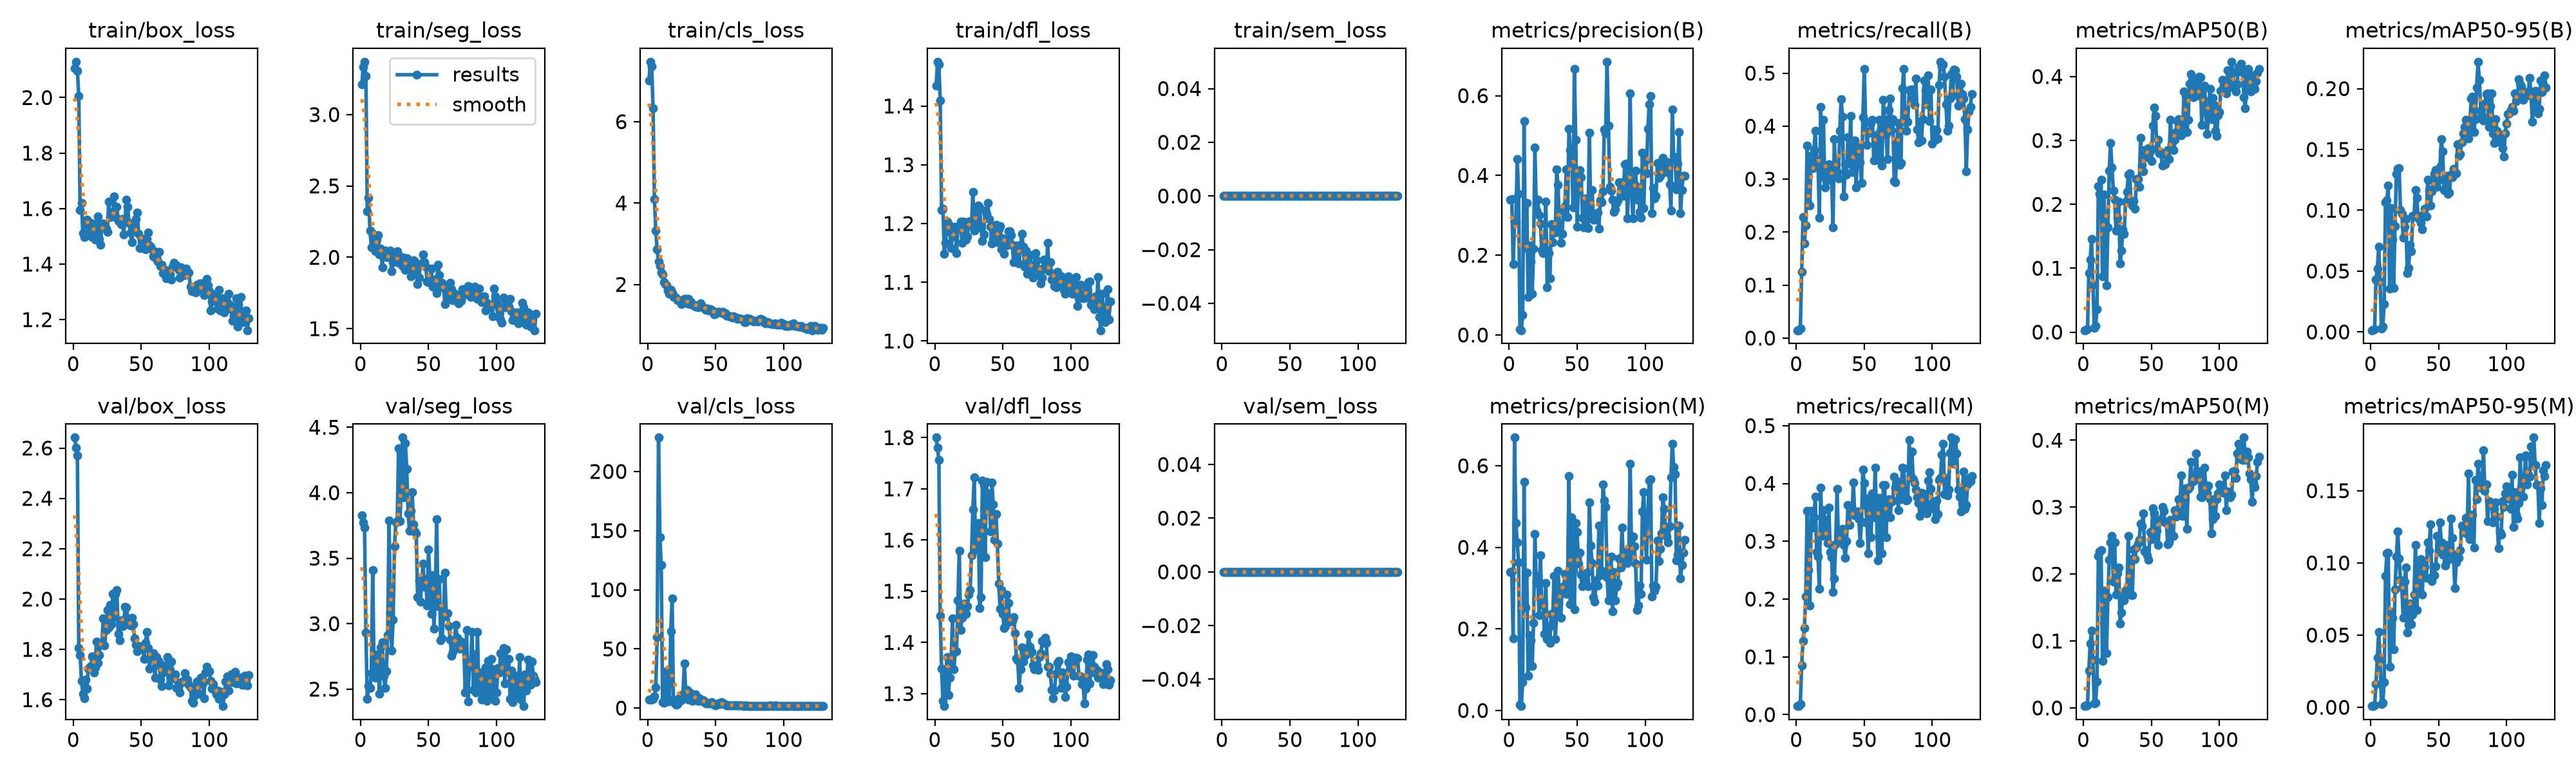

--- confusion_matrix.png ---


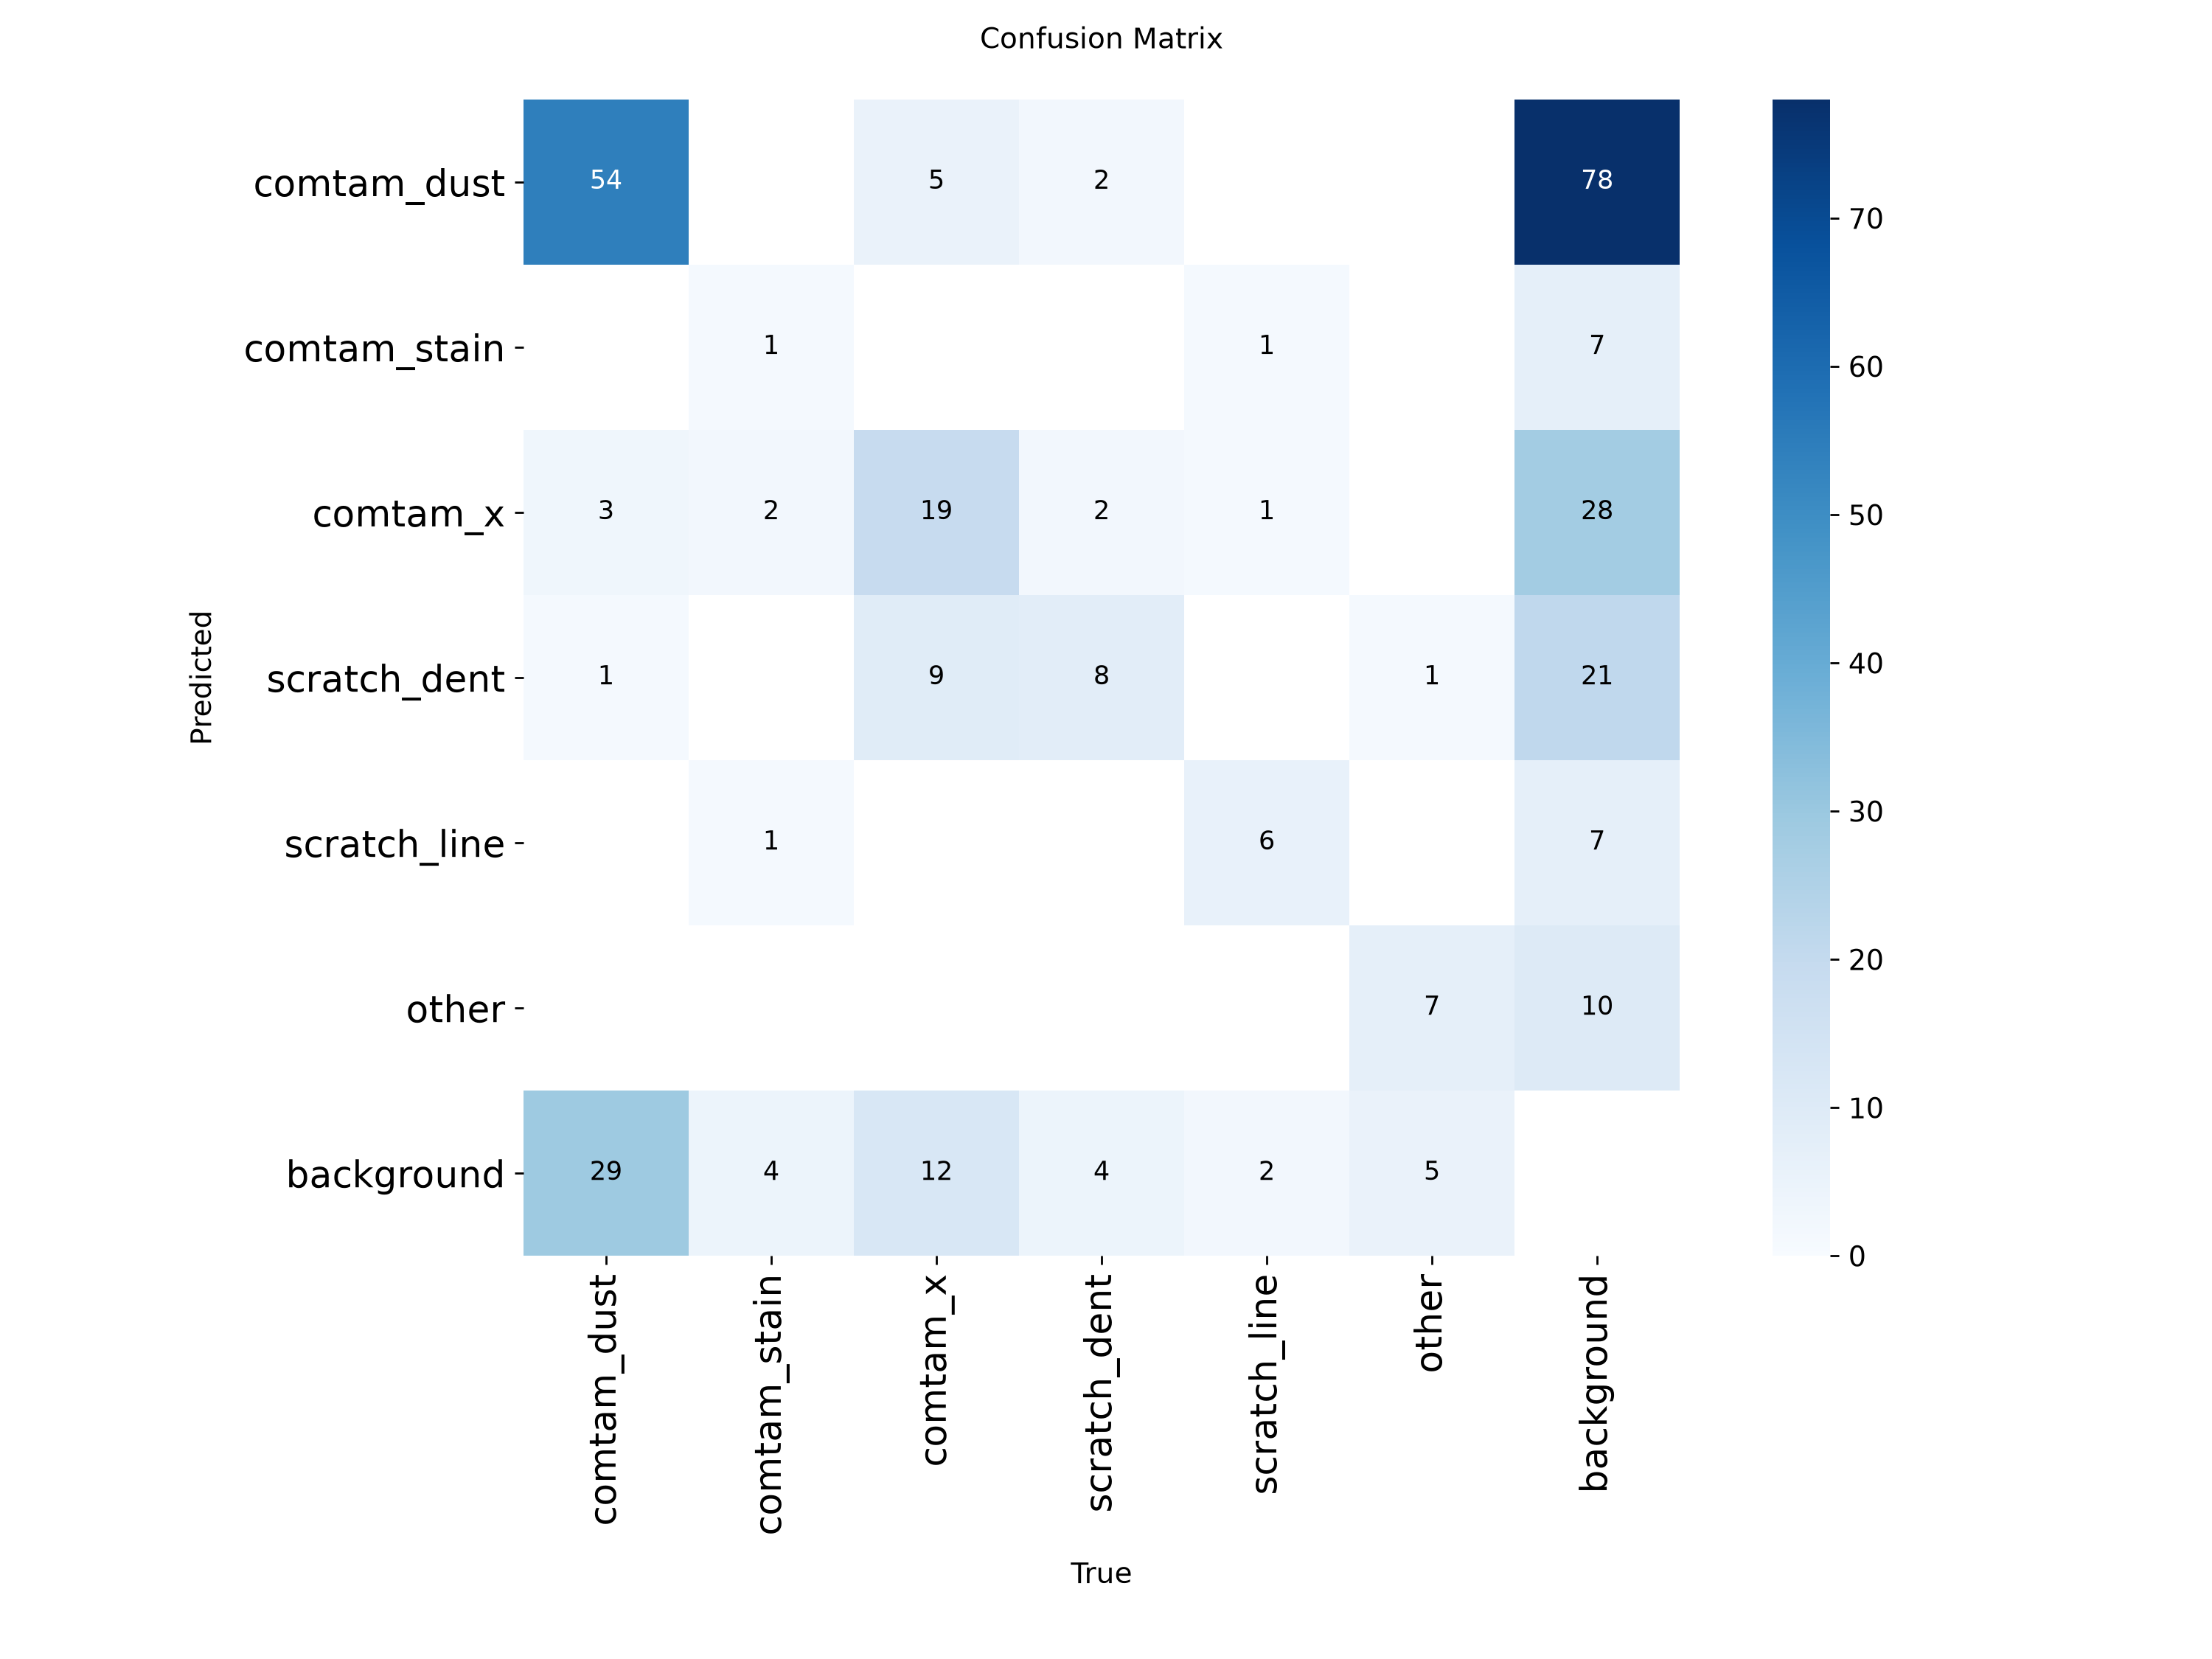

--- val_batch0_pred.jpg ---


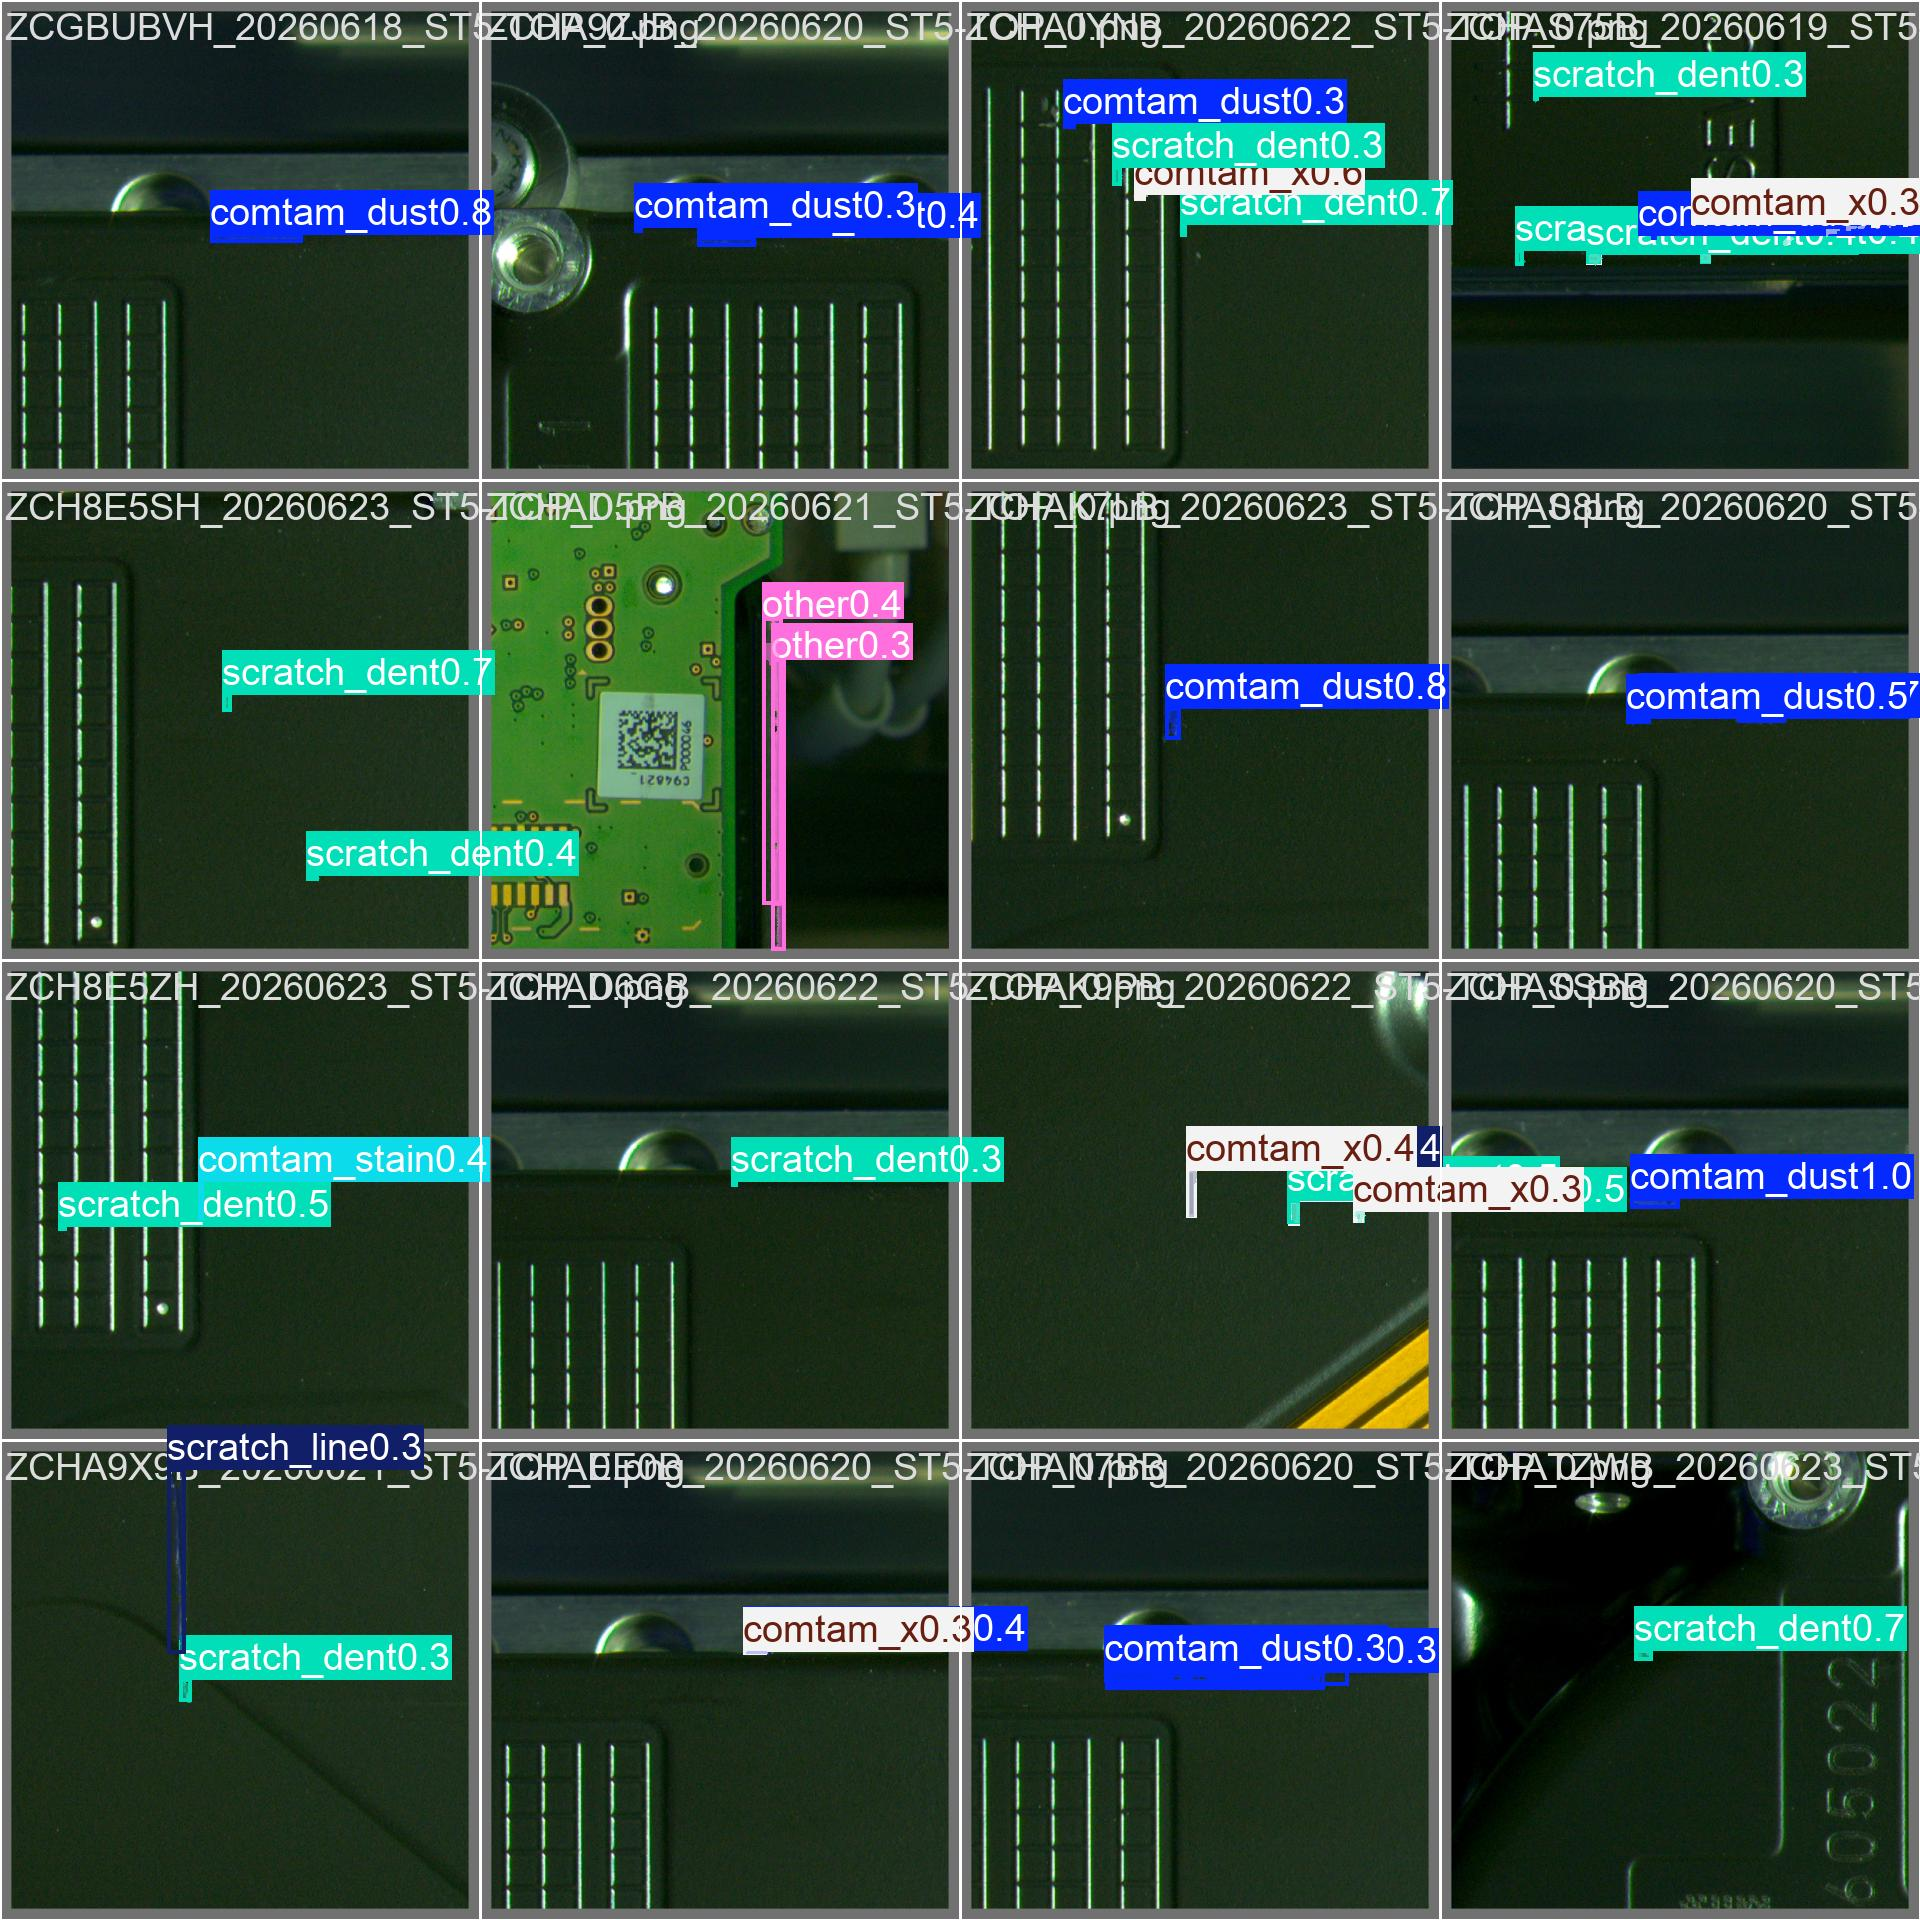

In [22]:
from IPython.display import Image, display

results_dir = resolve(cfg["training"]["output_dir"]) / "train"

for chart in ["results.png", "confusion_matrix.png", "val_batch0_pred.jpg"]:
    path = results_dir / chart
    if path.exists():
        print(f"--- {chart} ---")
        display(Image(filename=str(path), width=800))
    else:
        print(f"[not found] {path}")

---
## Cell 7 — STEP 4: Predict on New Images

### This is the payoff!

Now that the model is trained, you can point it at **brand new photos** it has never seen.

How it works:
1. Drop your unseen images into **`test_result/`**
2. Run this cell
3. Check **`test_result_output/`** — each image will have colored polygon masks drawn over any defects, with the class name and confidence score printed next to each one

**Confidence score** = how sure the model is (0.0 = no idea, 1.0 = totally certain).  
We filter out anything below 0.25 (25% confidence) — too low = probably a false alarm.

> **Note:** If `test_result/` doesn't exist or is empty, this cell tells you — nothing will crash.

In [23]:
from ultralytics import YOLO

out_dir    = resolve(cfg["training"]["output_dir"])
best_ckpt  = out_dir / "train" / "weights" / "best.pt"
input_dir  = yolo_dir / "images" / "test"
output_dir = resolve("test_output")

if not best_ckpt.exists():
    print(f"No trained model found at {best_ckpt}")
    print("Run Step 3 (Train) first.")
elif not input_dir.exists():
    print(f"Test split not found: {input_dir}")
    print("Run Step 1 (Prepare Dataset) first.")
else:
    imgs = sorted(input_dir.glob('*.png')) + sorted(input_dir.glob('*.jpg'))
    if not imgs:
        print(f"No images found in {input_dir}")
    else:
        output_dir.mkdir(exist_ok=True)

        print(f"Model  : {best_ckpt}")
        print(f"Input  : {input_dir}  ({len(imgs)} images)")
        print(f"Output : {output_dir}")
        print()

        model = YOLO(best_ckpt)
        model.predict(
            source=str(input_dir),
            save=True,
            project=str(output_dir.parent),
            name=output_dir.name,
            exist_ok=True,
            conf=0.25,
            verbose=True,
        )

        print(f"\nDone! Annotated images saved to: {output_dir}/")

Model  : C:\Thawanrat_Internship-Project\ML_pipeline\models\train\weights\best.pt
Input  : C:\Thawanrat_Internship-Project\ML_pipeline\test_result  (235 images)
Output : C:\Thawanrat_Internship-Project\ML_pipeline\test_result_output


image 1/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCH23KVB_20260625_ST5-TOP_0.png: 640x640 1 comtam_dust, 36.0ms
image 2/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHAA26B_20260625_ST5-TOP_0.png: 640x640 3 comtam_dusts, 39.4ms
image 3/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEB6B_20260625_ST5-TOP_0.png: 640x640 2 others, 36.3ms
image 4/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBRB_20260625_ST5-TOP_0.png: 640x640 2 others, 36.2ms
image 5/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBXB_20260625_ST5-TOP_0.png: 640x640 2 others, 23.3ms
image 6/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBZB_20260625_ST5-TOP_0.png: 640x640 2 others, 8.3ms

---
## Cell 8 — Show Prediction Results

Displays the annotated output images right here in the notebook — no need to open a folder.  
Each image shows colored polygon masks with class labels and confidence scores.

In [2]:
from IPython.display import Image, display

output_dir = resolve("test_output")

result_imgs = sorted(output_dir.glob("*.png")) + sorted(output_dir.glob("*.jpg"))

if not result_imgs:
    print("No output images found. Run Step 4 first.")
else:
    print(f"Showing {len(result_imgs)} prediction result(s):")
    for img_path in result_imgs:
        print(f"\n{img_path.name}")
        display(Image(filename=str(img_path), width=700))

NameError: name 'resolve' is not defined

---
## Cell 9 — Side-by-Side Comparison: Original vs Prediction

Shows the original test image next to the predicted (annotated) image, side by side.
Change **`n`** to control how many pairs to display and save.

Saved images land in **`test_result_side_by_side/`** — one file per pair, same filename as the original.

In [ ]:
n = 3   # number of pairs to display in the notebook (all pairs are always saved)

from PIL import Image
import matplotlib.pyplot as plt

input_dir = yolo_dir / "images" / "test"
pred_dir  = resolve("test_output")
side_dir  = resolve("test_result_side_by_side")
side_dir.mkdir(exist_ok=True)

orig_imgs = sorted(input_dir.glob("*.png")) + sorted(input_dir.glob("*.jpg"))
pred_map  = {p.stem: p for p in list(pred_dir.glob("*.png")) + list(pred_dir.glob("*.jpg"))}

pairs = [(img, pred_map[img.stem]) for img in orig_imgs if img.stem in pred_map]

if not pairs:
    print("No matching pairs found. Run Step 4 (Predict) first.")
else:
    for i, (orig_path, pred_path) in enumerate(pairs):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        ax1.imshow(Image.open(orig_path).convert("RGB"))
        ax1.set_title("Original", fontsize=13)
        ax1.axis("off")
        ax2.imshow(Image.open(pred_path).convert("RGB"))
        ax2.set_title("Prediction", fontsize=13)
        ax2.axis("off")
        fig.suptitle(orig_path.name, fontsize=11, y=0.02)
        plt.tight_layout()
        fig.savefig(side_dir / orig_path.stem, dpi=150, bbox_inches="tight")
        if i < n:
            plt.show()
        plt.close(fig)
        print(f"Saved: {orig_path.name}")

    print(f"\n{len(pairs)} saved, {min(n, len(pairs))} shown. Folder: {side_dir}/")

---
## Cell 10 — Predict on a Different Folder (Optional)

Want to run prediction on a folder other than `test_result/`?  
Just change `MY_FOLDER` below to your folder name.

In [25]:
MY_FOLDER = "test_result"   # <-- change this to any folder you want

from ultralytics import YOLO

out_dir    = resolve(cfg["training"]["output_dir"])
best_ckpt  = out_dir / "train" / "weights" / "best.pt"
input_dir  = resolve(MY_FOLDER)
output_dir = resolve(MY_FOLDER + "_output")

if not best_ckpt.exists():
    print(f"No trained model found at {best_ckpt}")
    print("Run Step 3 (Train) first.")
elif not input_dir.exists():
    print(f"Input folder not found: {input_dir}")
    print("Create the folder and add some .png or .jpg images to it.")
else:
    imgs = sorted(input_dir.glob('*.png')) + sorted(input_dir.glob('*.jpg'))
    if not imgs:
        print(f"No images found in {input_dir}")
    else:
        output_dir.mkdir(exist_ok=True)

        print(f"Model  : {best_ckpt}")
        print(f"Input  : {input_dir}  ({len(imgs)} images)")
        print(f"Output : {output_dir}")
        print()

        model = YOLO(best_ckpt)
        model.predict(
            source=str(input_dir),
            save=True,
            project=str(output_dir.parent),
            name=output_dir.name,
            exist_ok=True,
            conf=0.25,
            verbose=True,
        )

        print(f"\nDone! Annotated images saved to: {output_dir}/")

Model  : C:\Thawanrat_Internship-Project\ML_pipeline\models\train\weights\best.pt
Input  : C:\Thawanrat_Internship-Project\ML_pipeline\test_result  (235 images)
Output : C:\Thawanrat_Internship-Project\ML_pipeline\test_result_output


image 1/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCH23KVB_20260625_ST5-TOP_0.png: 640x640 1 comtam_dust, 15.6ms
image 2/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHAA26B_20260625_ST5-TOP_0.png: 640x640 3 comtam_dusts, 13.4ms
image 3/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEB6B_20260625_ST5-TOP_0.png: 640x640 2 others, 15.6ms
image 4/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBRB_20260625_ST5-TOP_0.png: 640x640 2 others, 16.0ms
image 5/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBXB_20260625_ST5-TOP_0.png: 640x640 2 others, 17.1ms
image 6/235 C:\Thawanrat_Internship-Project\ML_pipeline\test_result\ZCHBEBZB_20260625_ST5-TOP_0.png: 640x640 2 others, 16.4m